# **Ejercicio Integrador - Clase 3 - 4.1**

Supongamos que estamos analizando un dataset de clientes de un banco que busca segmentar su base de clientes según sus ingresos y años de experiencia.

## 1 - Análisis Exploratorio de Datos (EDA)

* Generar histogramas de Edad e Ingresos.
* Calcular la correlación entre Edad, Ingresos y Experiencia.
* Visualizar relaciones con diagramas de dispersión.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.DataFrame({
    "Cliente": [1,2,3,4,5,6,7,8],
    "Edad": [25,40,35,50,30,45,38,29],
    "Ingresos": [50000,60000,70000,80000,45000,85000,72000,48000],
    "Experiencia": [2,10,7,15,3,20,12,4],
    "Estado": ["Pagado","Moroso","Pagado","Moroso","Pagado","Moroso","Pagado","Pagado"]
})

In [2]:
df

,Cliente,Edad,Ingresos,Experiencia,Estado
0,1,25,50000,2,Pagado
1,2,40,60000,10,Moroso
2,3,35,70000,7,Pagado
3,4,50,80000,15,Moroso
4,5,30,45000,3,Pagado
5,6,45,85000,20,Moroso
6,7,38,72000,12,Pagado
7,8,29,48000,4,Pagado


In [3]:
# Verificar valores faltantes, duplicados o atípicos.
print(df.isnull().sum())
print(df.duplicated().sum())
print(df[df["Edad"] < 0])

Cliente        0
Edad           0
Ingresos       0
Experiencia    0
Estado         0
dtype: int64
0
Empty DataFrame
Columns: [Cliente, Edad, Ingresos, Experiencia, Estado]
Index: []


In [4]:
# Resumen Estadístico
df.describe()

,Cliente,Edad,Ingresos,Experiencia
count,8.00000,8.000000,8.000000,8.00000
mean,4.50000,36.500000,63750.000000,9.12500
std,2.44949,8.468429,15238.578861,6.33443
min,1.00000,25.000000,45000.000000,2.00000
25%,2.75000,29.750000,49500.000000,3.75000
50%,4.50000,36.500000,65000.000000,8.50000
75%,6.25000,41.250000,74000.000000,12.75000
max,8.00000,50.000000,85000.000000,20.00000


El conjunto de datos está compuesto por 8 registros, sin valores faltantes ni duplicados, lo que indica una buena calidad inicial de la información.

En la variable **edad**, la media es de 36,5 años, con un valor mínimo de 25 y un máximo de 50, lo que muestra una distribución relativamente equilibrada y sin valores extremos. Además, el 25% de los clientes tiene menos de 30 años, el 50% se encuentra por debajo de 36,5 años y el 75% tiene menos de 41 años. La desviación estándar es de 8,47, lo que refleja una dispersión moderada en las edades.

Respecto de los **ingresos**, el promedio es de 63.750, con valores que oscilan entre 45.000 y 85.000, evidenciando cierta variabilidad económica entre los clientes. El 25% percibe menos de 49.500, el 50% gana menos de 65.000 y el 75% tiene ingresos inferiores a 74.000. La desviación estándar es de 15.238,58, lo que indica una dispersión considerable en esta variable.

En cuanto a la **experiencia**, el promedio es de 9,12 años, con un mínimo de 2 y un máximo de 20, lo que señala la presencia de perfiles tanto junior como de mayor trayectoria. El 25% de los clientes tiene menos de 3,75 años de experiencia, el 50% menos de 8,5 años y el 75% menos de 12,75 años. La desviación estándar es de 6,33, mostrando también una variabilidad importante en esta característica.

En conjunto, los datos reflejan una muestra heterogénea en términos de edad, ingresos y experiencia, lo que puede resultar útil para realizar análisis posteriores, como segmentación de clientes o identificación de perfiles.


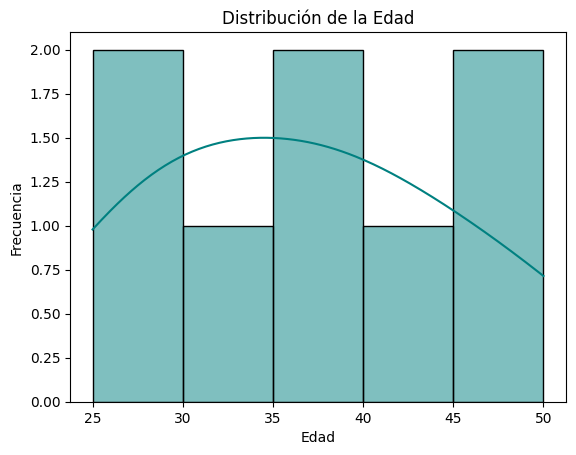

In [5]:
sns.histplot(df["Edad"], bins=5, kde=True, color="teal", edgecolor="black")
plt.title("Distribución de la Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


El pico de la curva sugiere que la mayor concentración de clientes se encuentra aproximadamente entre los 30 y 45 años. Sin embargo, dado el tamaño reducido de la muestra, esta concentración debe interpretarse con cautela, ya que la curva representa una estimación suavizada de la distribución.

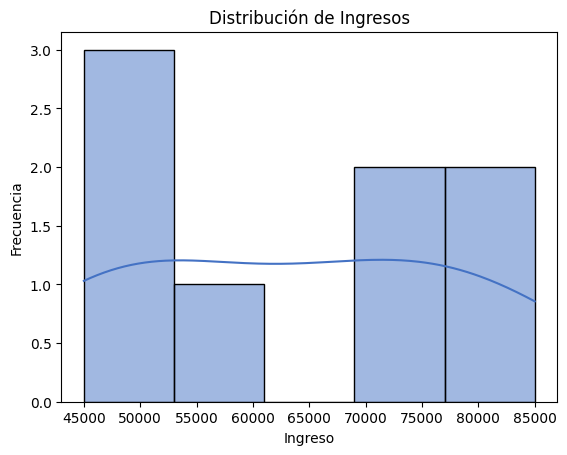

In [6]:
sns.histplot(df["Ingresos"], bins=5, kde=True, color="#4472C4", edgecolor="black")
plt.title("Distribución de Ingresos")
plt.xlabel("Ingreso")
plt.ylabel("Frecuencia")
plt.show()


La curva suavizada sugiere la posible presencia de dos zonas de concentración: una en los ingresos más bajos (alrededor de 45.000–50.000) y otra en los ingresos más altos (cercanos a 70.000–85.000). Esto podría indicar cierta segmentación económica dentro del grupo de clientes.

In [7]:
# Análisis Multivariado: Correlación entre Edad Ingreso y Experiencia
print(df[["Edad", "Ingresos", "Experiencia"]].corr())

                Edad  Ingresos  Experiencia
Edad         1.00000  0.872330     0.912120
Ingresos     0.87233  1.000000     0.928305
Experiencia  0.91212  0.928305     1.000000


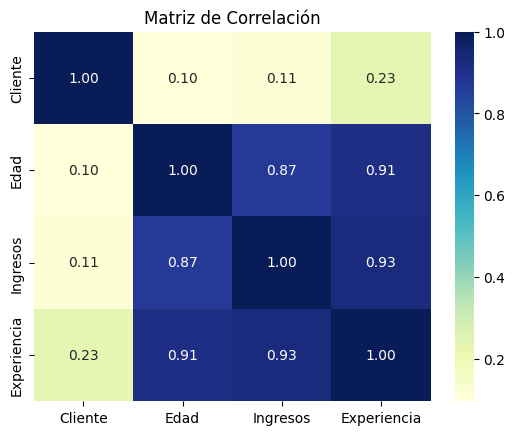

In [8]:
# Matriz de correlación (solo variables numéricas)
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

Cada celda muestra ***el coeficiente de correlación de Pearson*** entre dos variables:

La matriz de correlación fue representada utilizando una escala de color uniforme, donde los tonos más oscuros indican una mayor correlación entre variables, mientras que los tonos más claros representan relaciones más débiles.

Valores cercanos a +1: correlación positiva fuerte.

Valores cercanos a 0: sin correlación lineal.

Valores cercanos a –1: correlación negativa fuerte

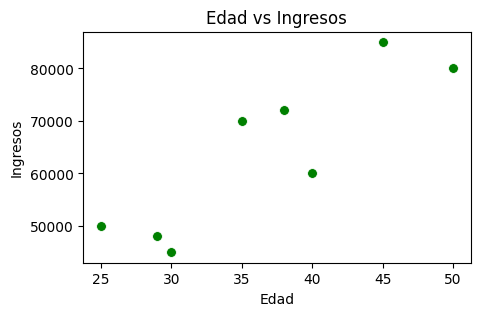

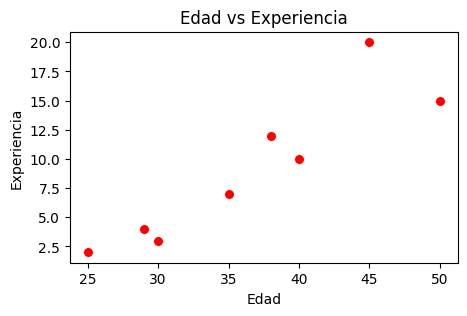

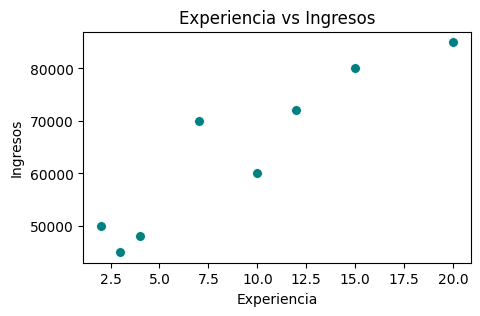

In [9]:
# Edad vs Ingresos
plt.figure(figsize=(5,3))
sns.scatterplot(x="Edad", y="Ingresos", data=df, color ="green", s=50)
plt.title("Edad vs Ingresos")
plt.show()

# Edad vs Experiencia
plt.figure(figsize=(5,3))
sns.scatterplot(x="Edad", y="Experiencia", data=df, color ="red", s=50)
plt.title("Edad vs Experiencia")
plt.show()

# Experiencia vs Ingresos
plt.figure(figsize=(5,3))
sns.scatterplot(x="Experiencia", y="Ingresos", data=df, color ="teal", s=50)
plt.title("Experiencia vs Ingresos")
plt.show()

**1. Edad vs Ingresos**

Existe una relación positiva fuerte, lo que indica que los clientes de mayor edad tienden a tener ingresos más altos.

**2. Edad vs Experiencia**

Hay una relación muy fuerte (casi lineal) entre edad y experiencia. Es lógico: a mayor edad, más años trabajados.

**3. Experiencia vs Ingresos**

Existe una fuerte relación positiva, lo que indica que a mayor experiencia, mayores ingresos.


##2 - Aplicación de PCA para Reducción de Dimensionalidad
* Normalizar los datos antes de aplicar PCA.
* Calcular cuántas componentes principales explican el 90% de la varianza.
* Visualizar los datos en 2D usando las dos primeras componentes principales.


In [10]:
import numpy as np
# NORMALIZACIÓN DE DATOS
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])

# APLICACIÓN DE PCA - 3 variables a 2 componentes principales.
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Se convierte a DataFrame para mejor manejo
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

# Varianza por componente.
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# Varianza acumulada.
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print("Varianza acumulada:")
print(varianza_acumulada)
# Cantidad de componentes del 90%.
n_componentes = np.argmax(varianza_acumulada >= 0.90) + 1
print("Cantidad de componentes necesarias:", n_componentes)


Varianza explicada por cada componente:
[0.9362353  0.04299134]
Varianza acumulada:
[0.9362353  0.97922665]
Cantidad de componentes necesarias: 1


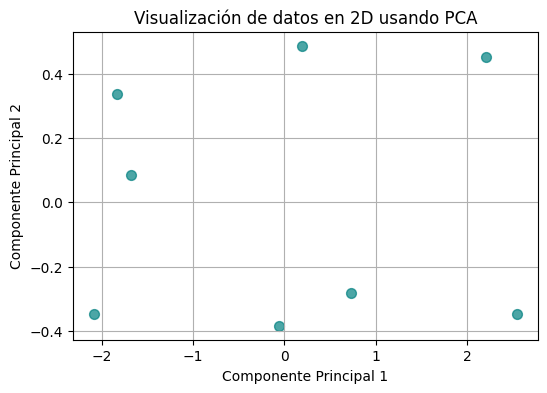

In [11]:

plt.figure(figsize=(6,4))
plt.scatter(df_pca["PC1"], df_pca["PC2"], color="teal", s=50, alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualización de datos en 2D usando PCA")

plt.grid()
plt.show()

El análisis confirma que el conjunto de datos presenta una estructura esencialmente unidimensional, lo que permite reducir significativamente la complejidad sin pérdida relevante de información.

##3 - Segmentación de Clientes con Clustering
* Aplicar K-Means Clustering con 3 clusters sobre los datos originales y luego sobre los datos transformados por PCA.
* Comparar los resultados y analizar si el agrupamiento cambia después de la reducción de dimensionalidad.
* Visualizar los clusters con gráficos de dispersión en 2D.

In [12]:
# APLICACIÓN DE K-MEANS
# Se agrupan los datos en 3 clusters según similitud
kmeans = KMeans(n_clusters=3, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)
conteo_clusters = df_pca["Cluster"].value_counts()
print("Cantidad de datos por cluster:")
print(conteo_clusters)

Cantidad de datos por cluster:
Cluster
2    3
0    3
1    2
Name: count, dtype: int64


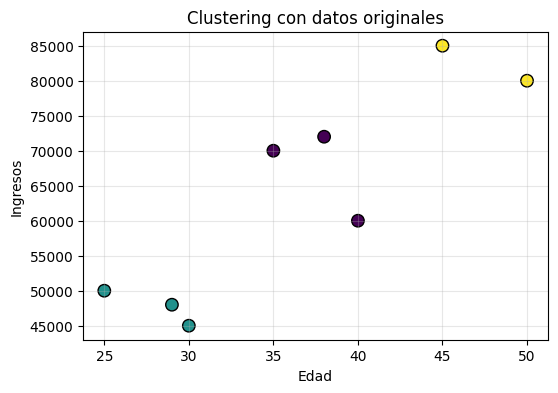

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df["Edad"], df["Ingresos"],
            c=df_pca["Cluster"], cmap="viridis",
            s=80, edgecolor="black")

plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.title("Clustering con datos originales")

plt.grid(alpha=0.3)
plt.show()

In [14]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(df_pca)

df_pca["Cluster"] = clusters_pca
conteo_clusters = df_pca["Cluster"].value_counts()
print("Cantidad de datos por cluster:")
print(conteo_clusters)

Cantidad de datos por cluster:
Cluster
1    3
0    3
2    2
Name: count, dtype: int64


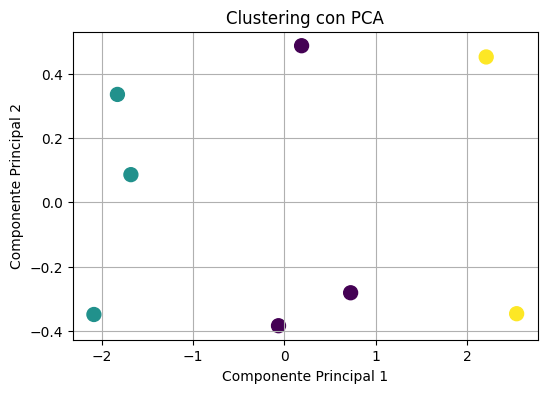

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df_pca["PC1"],df_pca["PC2"],c=df_pca["Cluster"],s=100,cmap="viridis"
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clustering con PCA")

plt.grid()
plt.show()

“En los datos originales, el clustering está sesgado por la variable ingresos debido a su escala. En cambio, al aplicar PCA previamente estandarizado, los datos se transforman en nuevas variables que concentran la información, logrando una mejor separación de los clusters.”

##4 - Interacción con una Herramienta de IA (LLM)
* Hacer una consulta a ChatGPT, Gemini u otra herramienta LLM para obtener insights sobre los clusters.
* Ejemplo de consulta: "Tengo datos de clientes con variables de edad, ingresos y experiencia. ¿Qué técnicas avanzadas puedo usar para mejorar la segmentación?"
*Comparar la respuesta con lo aprendido en la clase y reflexionar sobre su utilidad.


Se utilizó una herramienta de inteligencia artificial (ChatGPT) para complementar el análisis. Como resultado, se sugirió explorar el uso del algoritmo DBSCAN para detectar posibles outliers o agrupaciones no lineales que K-Means podría no identificar. Además, se recomendó analizar la varianza dentro de cada cluster para evaluar su homogeneidad y validar la calidad de la segmentación obtenida. También podría usarse clustering jerárquico, que permite ver cómo se van formando los grupos paso a paso. Estas alternativas pueden aportar una visión más completa de la segmentación.